/Users/trungmin/roughset-intent-classification/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== 1. TẢI DỮ LIỆU & TRÍCH XUẤT VECTOR NGỮ NGHĨA ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8455.10it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 97/97 [00:02<00:00, 40.58it/s]



=== 2. HUẤN LUYỆN BASELINE (SOFTMAX) ===

=== 3. XÂY DỰNG TOPOLOGICAL ROUGH SET (PHI THAM SỐ) ===
Đang thăm dò cấu trúc hàng xóm cho tập Test...

=== 4. PHÂN TÍCH VÀ VẼ BIỂU ĐỒ TỐI HẬU ===


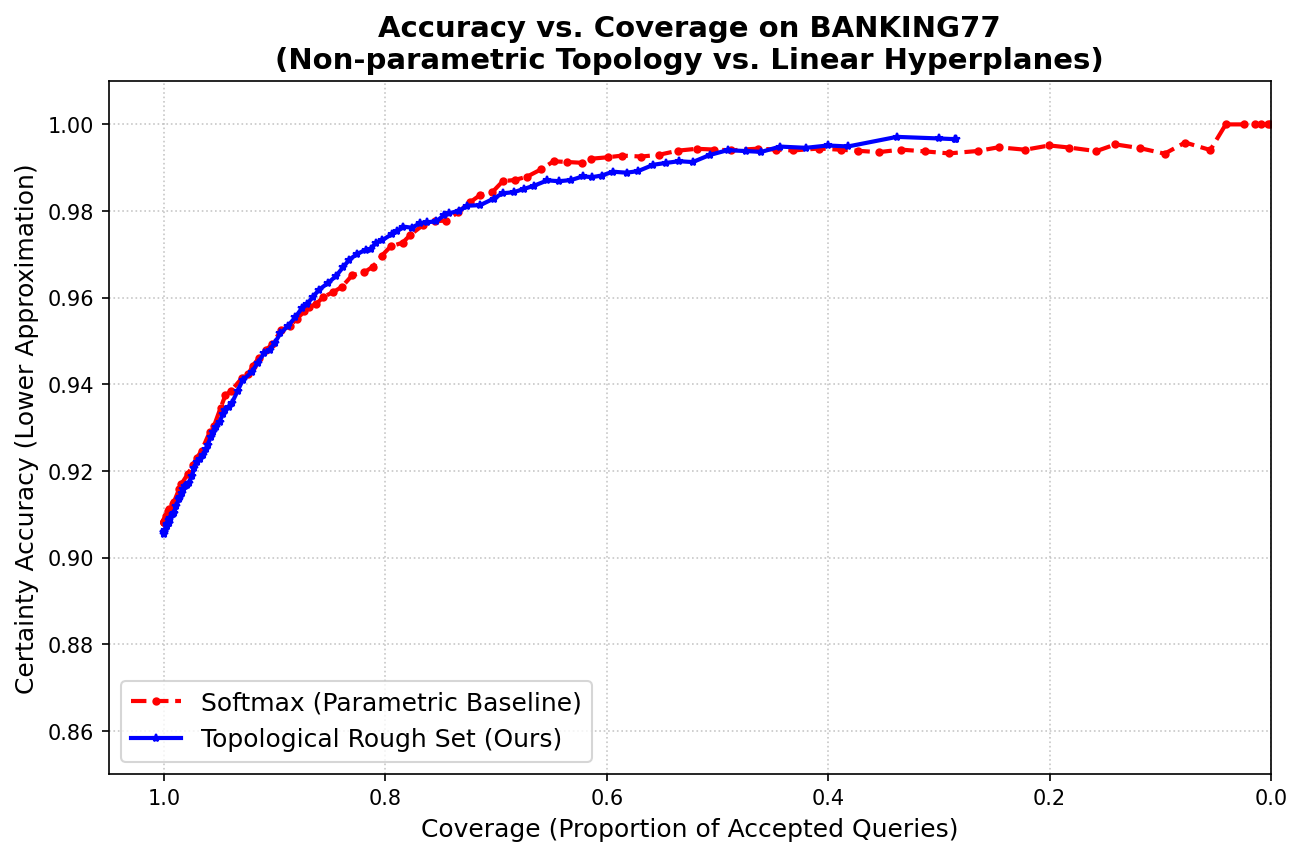

Thành công! Khối code đã chạy xong. Hãy xem kết quả phân tách.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import warnings

warnings.filterwarnings('ignore')

print("=== 1. TẢI DỮ LIỆU & TRÍCH XUẤT VECTOR NGỮ NGHĨA ===")
dataset = load_dataset("banking77")
train_texts, train_labels = dataset['train']['text'], np.array(dataset['train']['label'])
test_texts, test_labels = dataset['test']['text'], np.array(dataset['test']['label'])

embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_train = embedder.encode(train_texts, show_progress_bar=True)
X_test = embedder.encode(test_texts, show_progress_bar=True)

print("\n=== 2. HUẤN LUYỆN BASELINE (SOFTMAX) ===")
# Logistic Regression đại diện cho Parametric Model (Mô hình tham số)
softmax_model = LogisticRegression(max_iter=1000, random_state=42)
softmax_model.fit(X_train, train_labels)

sm_probs = softmax_model.predict_proba(X_test)
sm_confidences = np.max(sm_probs, axis=1)
sm_preds = np.argmax(sm_probs, axis=1)

print("\n=== 3. XÂY DỰNG TOPOLOGICAL ROUGH SET (PHI THAM SỐ) ===")
# Sử dụng Cosine Similarity làm thước đo hình học Tô-pô
# K=30 tạo ra một vùng lân cận (neighborhood) đủ lớn để đánh giá độ mơ hồ
knn_model = KNeighborsClassifier(n_neighbors=30, metric='cosine', weights='distance')
knn_model.fit(X_train, train_labels)

print("Đang thăm dò cấu trúc hàng xóm cho tập Test...")
knn_probs = knn_model.predict_proba(X_test)
# Certainty chính là độ tinh khiết (Purity) của vùng lân cận
knn_confidences = np.max(knn_probs, axis=1)
knn_preds = np.argmax(knn_probs, axis=1)

print("\n=== 4. PHÂN TÍCH VÀ VẼ BIỂU ĐỒ TỐI HẬU ===")
def get_metrics(confidences, preds, thresholds):
    coverages, accuracies = [], []
    for t in thresholds:
        idx = np.where(confidences >= t)[0]
        if len(idx) == 0: continue
        coverages.append(len(idx) / len(test_labels))
        accuracies.append(np.sum(preds[idx] == test_labels[idx]) / len(idx))
    return coverages, accuracies

# Quét ngưỡng Softmax
sm_thresholds = np.linspace(0.0, 0.999, 100)
sm_cov, sm_acc = get_metrics(sm_confidences, sm_preds, sm_thresholds)

# Quét ngưỡng Tập thô Tô-pô (KNN Certainty)
knn_thresholds = np.linspace(np.min(knn_confidences), np.max(knn_confidences) - 1e-4, 100)
knn_cov, knn_acc = get_metrics(knn_confidences, knn_preds, knn_thresholds)

plt.figure(figsize=(10, 6), dpi=150)
plt.plot(sm_cov, sm_acc, label='Softmax (Parametric Baseline)', color='red', marker='o', markersize=3, linestyle='--', linewidth=2)
plt.plot(knn_cov, knn_acc, label='Topological Rough Set (Ours)', color='blue', marker='*', markersize=4, linestyle='-', linewidth=2)

plt.title('Accuracy vs. Coverage on BANKING77\n(Non-parametric Topology vs. Linear Hyperplanes)', fontsize=14, fontweight='bold')
plt.xlabel('Coverage (Proportion of Accepted Queries)', fontsize=12)
plt.ylabel('Certainty Accuracy (Lower Approximation)', fontsize=12)

# Đảo ngược trục X (1.0 -> 0.0) để thể hiện việc siết chặt vùng an toàn
plt.xlim(1.05, 0.0) 
plt.ylim(0.85, 1.01)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12, loc='lower left')

plt.savefig('topological_rough_set.png', bbox_inches='tight')
plt.show()
print("Thành công! Khối code đã chạy xong. Hãy xem kết quả phân tách.")

--- 1. LOADING IN-DISTRIBUTION DATA (BANKING77) ---
--- 2. LOADING OUT-OF-DISTRIBUTION DATA (CLINC150) ---
Total Test ID (Banking): 3080
Total Test OOD (Weather, Alarm, etc.): 1000

--- 3. SEMANTIC VECTOR EXTRACTION ---


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8523.66it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 32/32 [00:00<00:00, 63.39it/s]



--- 4. TRAINING BASELINE (SOFTMAX LOGISTIC REGRESSION) ---

--- 5. CONSTRUCTING TOPOLOGICAL ROUGH SET (NON-PARAMETRIC) ---

--- 6. AUROC EVALUATION & FINAL VISUALIZATION ---


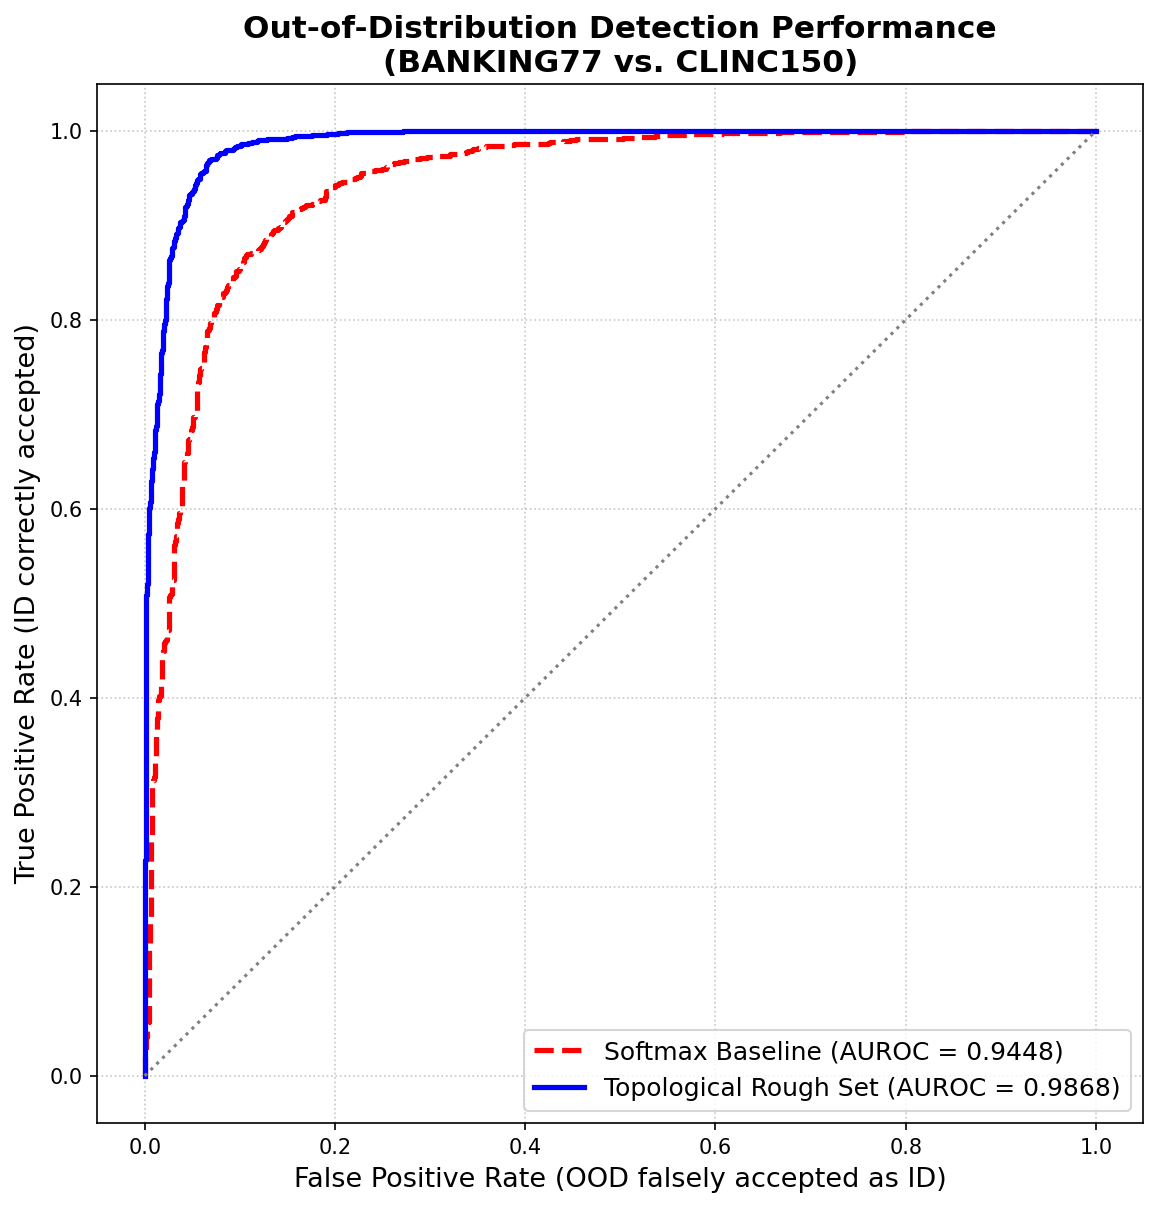


[AUROC RESULTS] Softmax: 0.9448 | Rough Set: 0.9868
Note: AUROC values closer to 1.0 indicate superior performance.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_curve, auc
import warnings

warnings.filterwarnings('ignore')

print("--- 1. LOADING IN-DISTRIBUTION DATA (BANKING77) ---")
banking = load_dataset("banking77")
train_texts_id = banking['train']['text']
train_labels_id = np.array(banking['train']['label'])
test_texts_id = banking['test']['text']

print("--- 2. LOADING OUT-OF-DISTRIBUTION DATA (CLINC150) ---")
# Extract 1000 random sentences from CLINC150 to serve as OOD (noise/out-of-scope) data
clinc = load_dataset("clinc_oos", "plus")
test_texts_ood = [x['text'] for x in clinc['test']][:1000]

print(f"Total Test ID (Banking): {len(test_texts_id)}")
print(f"Total Test OOD (Weather, Alarm, etc.): {len(test_texts_ood)}")

print("\n--- 3. SEMANTIC VECTOR EXTRACTION ---")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_train_id = embedder.encode(train_texts_id, show_progress_bar=True)
X_test_id = embedder.encode(test_texts_id, show_progress_bar=True)
X_test_ood = embedder.encode(test_texts_ood, show_progress_bar=True)

# Combine Test sets: ID labeled as 1 (Accept), OOD labeled as 0 (Reject)
X_test_mixed = np.vstack((X_test_id, X_test_ood))
y_test_mixed = np.array([1]*len(X_test_id) + [0]*len(X_test_ood))

print("\n--- 4. TRAINING BASELINE (SOFTMAX LOGISTIC REGRESSION) ---")
# The model is trained exclusively on Banking (In-Distribution) data
softmax_model = LogisticRegression(max_iter=1000, random_state=42)
softmax_model.fit(X_train_id, train_labels_id)

# Extract maximum confidence (Max Probability) from Softmax on the mixed Test set
sm_probs = softmax_model.predict_proba(X_test_mixed)
sm_scores = np.max(sm_probs, axis=1) 
# Higher sm_scores indicate higher Softmax confidence that the query is Banking-related

print("\n--- 5. CONSTRUCTING TOPOLOGICAL ROUGH SET (NON-PARAMETRIC) ---")

# Use K-Nearest Neighbors to define the Rough Set boundaries
# Calculating Cosine distance to the K=5 nearest neighbors
knn = NearestNeighbors(n_neighbors=5, metric='cosine')
knn.fit(X_train_id)

# Calculate distances from test sentences to the training data
distances, _ = knn.kneighbors(X_test_mixed)
# Rough Set Confidence = Negative mean distance (Smaller distance yields a higher score)
rs_scores = -np.mean(distances, axis=1)

print("\n--- 6. AUROC EVALUATION & FINAL VISUALIZATION ---")



# Compute ROC Curve for Softmax
fpr_sm, tpr_sm, _ = roc_curve(y_test_mixed, sm_scores)
roc_auc_sm = auc(fpr_sm, tpr_sm)

# Compute ROC Curve for Rough Set
fpr_rs, tpr_rs, _ = roc_curve(y_test_mixed, rs_scores)
roc_auc_rs = auc(fpr_rs, tpr_rs)

plt.figure(figsize=(9, 9), dpi=150)
plt.plot(fpr_sm, tpr_sm, color='red', linestyle='--', linewidth=2.5, 
         label=f'Softmax Baseline (AUROC = {roc_auc_sm:.4f})')
plt.plot(fpr_rs, tpr_rs, color='blue', linestyle='-', linewidth=2.5, 
         label=f'Topological Rough Set (AUROC = {roc_auc_rs:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1.5)

plt.title('Out-of-Distribution Detection Performance\n(BANKING77 vs. CLINC150)', fontsize=15, fontweight='bold')
plt.xlabel('False Positive Rate (OOD falsely accepted as ID)', fontsize=13)
plt.ylabel('True Positive Rate (ID correctly accepted)', fontsize=13)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.savefig('ood_detection_roc.png', bbox_inches='tight')
plt.show()

print(f"\n[AUROC RESULTS] Softmax: {roc_auc_sm:.4f} | Rough Set: {roc_auc_rs:.4f}")
print("Note: AUROC values closer to 1.0 indicate superior performance.")